# Qubit coupled to Two-level system (TLS) with white noise

### Author: Daniel Gonçalves Benvenutti - UNICAMP
15 August 2025

Qutip Version: 5.2.0









In [1]:
# to use in google colab
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 15.5 MB/s eta 0:00:00


In [1]:
import qutip as qtp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import lsim, TransferFunction

## Simulation Parameters



In [2]:

# operators
sm=qtp.destroy(2)
sx=qtp.sigmax()
sz=qtp.sigmaz()
sy=qtp.sigmay()
n=sm.dag()*sm

sm0=qtp.tensor(sm, qtp.qeye(2))
sx0=qtp.tensor(sx, qtp.qeye(2))
sz0=qtp.tensor(sz, qtp.qeye(2))
sy0=qtp.tensor(sy, qtp.qeye(2))
n0=qtp.tensor(n, qtp.qeye(2))

sm1=qtp.tensor(qtp.qeye(2), sm)
sx1=qtp.tensor(qtp.qeye(2), sx)
sz1=qtp.tensor(qtp.qeye(2), sz)
n1=qtp.tensor(qtp.qeye(2), n)


# hamiltonian
def H(wq0,wq1, g, norm,  Ed1_t, Ed0_t, tlist):# wq[rad.GHz], Ed_t[rad.GHz], tlist[ns]
  # time independant hamiltonian (normalized by wq)
  H0 = -0.5*wq0*sz0
  H1 = -0.5*wq1*sz1
  Hint = g*(sm1.dag()*sm0+sm1*sm0.dag())
  H = (H0 + H1 + Hint)/norm

# Use basic hamiltonian if there's no drive
  if Ed1_t is None and Ed0_t is None:
    return H

  # time dependant hamiltonian
  # [time independant part, [operator,time dependant operator amplitude]]
  # [qubit, [drive]]
  #There is noise in TLS 1
  Ham = [H] #list with the time independant hamiltonians
  if Ed1_t is not None:
    Ham.append([sx1/norm,Ed1_t])
    #There's noise in Qubit 0
  if Ed0_t is not None:
    Ham.append([sx0/norm,Ed0_t])
  return qtp.QobjEvo(Ham,tlist=tlist*norm)

# colapse operators normalized by wq
def c_ops(T1_0,T2_0, T1_1,T2_1, norm): #T1[ns], T2[ns]
  if T2_0 is None or T2_1 is None:
    return [np.sqrt(1/T1_0/norm)*sm0, np.sqrt(1/T1_1/norm)*sm1]

  # (T2 must be T2<=2T1)
  elif T2_0>2*T1_0:
    raise Exception("Qubit T2 must be T2<=2T1")
  elif T2_1>2*T1_1:
    raise Exception("TLS T2 must be T2<=2T1")

  gamma_phi_0=1/T2_0-1/2/T1_0 #pure dephasing constant
  gamma_phi_1=1/T2_1-1/2/T1_1 #pure dephasing constant
  return [np.sqrt(1/T1_0/norm)*sm0,np.sqrt(gamma_phi_0/2/norm)*sz0, np.sqrt(1/T1_1/norm)*sm1,np.sqrt(gamma_phi_1/2/norm)*sz1, ]

def band_stop(tlist, x_t, f0=1,fc=1, n=1):
    # f0 central frequency [GHz]
    # fc bandwidth [GHz]
    # n stages

    #Y(s)=H(s)X(s)
    wc=2*np.pi*fc
    w0=2*np.pi*f0

    #multiples numerator and denominator polynomials of the filter transfer function n times
    num,den=[1],[1]
    for _ in range( n):
        num = np.polymul(num, [1, 0, w0**2])
        den = np.polymul(den, [1, wc, w0**2])
    #system H(s)^n
    tf=TransferFunction(num,den)

    #y(t)
    _, y_t, _ = lsim(tf, U=x_t, T=tlist)
    return y_t

def simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=None, Ed1=None, e="xyz"):
  # Normalization factor for simulation
  # user bigger between resonances
  norm=max(wq1, wq0)
  #print(f"norm: ",norm/np.pi/2, "GHz")
  #pi_pulse=np.pi/Ed #[ns]
  #print(f"pi pulse={pi_pulse:.2f} ns")

  lenght=2000 #ns
  #White noise generator
  tlist=np.linspace(0,lenght,int(lenght*200*norm/2/np.pi))
  if Ed0 is None:
     drive_data0= None
  else:
    drive_data0=Ed0(tlist)
  if Ed1 is None:
     drive_data1= None
  else:
    drive_data1=Ed1(tlist)

# Expected value operators in qubit 0
  e_ops=[]
  if "x" in e:
    e_ops.append(sx0)
  if "y" in e:
    e_ops.append(sy0)
  if "z" in e:
    e_ops.append(sz0)
  #simulation steps
  t=np.linspace(0,lenght,int(lenght*8*norm/2/np.pi)) #ns

  # simulation
  psi0=qtp.tensor(qtp.basis(2,0), qtp.basis(2,0))
  H_total=H(wq0,wq1, g, norm,drive_data1, drive_data0,tlist)
  col=c_ops(T1_0,T2_0, T1_1,T2_1,norm)

  res=qtp.mesolve(H_total,psi0,t*norm,c_ops=col,e_ops=e_ops,options=dict(nsteps=5000))
  return t, res

# Plots

In [ ]:
def plot_fft_tomography(t, expect, graphs="xyz"):
  # string graphs selects plots to make with presence of letters
  fig, axes = plt.subplots(len(graphs), 1, figsize=(8, int(3*len(graphs))))  # Adjust figure size as needed
  axes = np.atleast_1d(axes)

  # Calculate the corresponding frequencies
  freq = np.fft.rfftfreq(len(t), d=t[1] - t[0])

  # Plot sx
  if "x" in graphs:
    axes[graphs.index("x")].plot(freq, np.abs(np.fft.rfft(expect[graphs.index("x")])))
    axes[graphs.index("x")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("x")].set_ylabel('<σx>')
    axes[graphs.index("x")].set_title('Tomography of the noisy oscillation \n Expectation Value of $\\sigma_x$')


  # Plot sy
  if "y" in graphs:
    axes[graphs.index("y")].plot(freq, np.abs(np.fft.rfft(expect[graphs.index("y")])))
    axes[graphs.index("y")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("y")].set_ylabel('<σy>')
    axes[graphs.index("y")].set_title('Expectation Value of $\\sigma_y$')

  # Plot sz
  if "z" in graphs:
    axes[graphs.index("z")].plot(freq[1:], np.abs(np.fft.rfft(expect[graphs.index("z")])[1:]))
    axes[graphs.index("z")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("z")].set_ylabel('<σz>')
    axes[graphs.index("z")].set_title('Expectation Value of $\\sigma_z$')
    print(f"DC: {np.fft.rfft(expect[graphs.index("z")])[0]}")


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

def plot_tomography(t, expect, graphs="xyz"):
   # string graphs selects plots to make with presence of letters
  fig, axes = plt.subplots(len(graphs), 1, figsize=(8, int(3*len(graphs))))   # Adjust figure size as needed
  axes = np.atleast_1d(axes)
  # Plot sx
  if "x" in graphs:
    axes[graphs.index("x")].plot(t, expect[graphs.index("x")])
    axes[graphs.index("x")].set_xlabel('Time (ns)')
    axes[graphs.index("x")].set_ylabel('<σx>')
    axes[graphs.index("x")].set_title('Tomography of the noisy oscillation \n Expectation Value of $\\sigma_x$')


  # Plot sy
  if "y" in graphs:
    axes[graphs.index("y")].plot(t, expect[graphs.index("y")])
    axes[graphs.index("y")].set_xlabel('Time (ns)')
    axes[graphs.index("y")].set_ylabel('<σy>')
    axes[graphs.index("y")].set_title('Expectation Value of $\\sigma_y$')

  # Plot sz
  if "z" in graphs:
    axes[graphs.index("z")].plot(t, expect[graphs.index("z")])
    axes[graphs.index("z")].set_xlabel('Time (ns)')
    axes[graphs.index("z")].set_ylabel('<σz>')
    axes[graphs.index("z")].set_title('Expectation Value of $\\sigma_z$')


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

def diffusive_scale(dt, signal):
    """
    Returns the slope of variance vs lag in log-log scale
    For pure Brownian motion, slope ≈ 1
    """
    n = len(signal)
    lags = np.arange(1, n//2)
    variances = [np.var(signal[lag:] - signal[:-lag]) for lag in lags]
    slope, _ = np.polyfit(np.log(dt*lags), np.log(variances), 1)
    #diffusive scale
    D=slope
    return D

def lorenztian_fit(t, sigz, T2, split =100):
    # Calculate the corresponding frequencies
  dt=t[1]-t[0]
  freq = np.fft.rfftfreq(len(t), d=dt)

  start=1 # Remove DC
  split=100
  X=np.abs(np.fft.rfft(sigz))[start:split]
  freq_subset = freq[start:split]

  # Define the zero-centered Lorentzian function
  def lorentzian(f, A, gamma,offset):
    return A / (1 + (f/gamma)**2)+offset

  # Fit the Lorentzian function to the data
  popt, pcov = curve_fit(lorentzian, freq_subset, X,p0=[500,1/T2/np.pi, 10])

  # Get the fitted parameters
  A_fit, gamma_fit, offset_fit = popt

  # Generate the fitted curve
  X_fit = lorentzian(freq_subset, A_fit, gamma_fit, offset_fit)

  # Plot the original data and the fitted curve
  plt.plot(freq_subset, X, label='Original Data')
  plt.plot(freq_subset, X_fit, label=fr'$ T_2 \approx {1/gamma_fit/np.pi:.2f} ns$', color='red')
  plt.xlabel('Frequency (GHz)')
  plt.ylabel('<σz>')
  plt.title(f'Expectation Value of $\\sigma_z$ with Lorentzian Fit')
  plt.legend()
  plt.show()

  print(f"Fitted Offset: {offset_fit:.2f}")
  print(f"Fitted Amplitude (S0): {A_fit:.2f}")
  print(f"Fitted T2 {1/gamma_fit/np.pi:.2f} ns")
  print(f"std of increments (volatility): {np.var([j-i for i, j in zip(sigz[:-1], sigz[1:])])}")
def lorenztian_fit2(t, sigz, T2, peak,zoom=0.5):
    # Calculate the corresponding frequencies
  dt=t[1]-t[0]
  freq = np.fft.rfftfreq(len(t), d=dt)

  start=np.where(freq>=peak-zoom)[0][0]
  split=np.where(freq<=peak+zoom)[0][-1]
  X=np.abs(np.fft.rfft(sigz))[start:split]
  freq_subset = freq[start:split]

  # Define the zero-centered Lorentzian function
  def lorentzian(f, A, gamma,offset,f0):
    return A / (1 + ((f-f0)/gamma)**2)+offset
      # Plot the original data and the fitted curve
  plt.plot(freq_subset, X, label='Original Data')

  try:
    # Fit the Lorentzian function to the data
    popt, pcov = curve_fit(lorentzian, freq_subset, X,p0=[80,1/T2/np.pi, 10, peak])
  except:
    pass
  else:
    # Get the fitted parameters
    A_fit, gamma_fit, offset_fit, f0_fit = popt

    # Generate the fitted curve
    X_fit = lorentzian(freq_subset, A_fit, gamma_fit, offset_fit, f0_fit)
    plt.plot(freq_subset, X_fit, label=fr'$ T_2 \approx {1/gamma_fit/np.pi:.2f} ns$', color='red')
    print(f"Fitted Offset: {offset_fit:.2f}")
    print(f"Fitted Amplitude (S0): {A_fit:.2f}")
    print(f"Fitted T2 {1/gamma_fit/np.pi:.2f} ns")
    print(f"Fitted f0 {f0_fit:.2f} GHz")


  plt.xlabel('Frequency (GHz)')
  plt.ylabel('<σz>')
  plt.title(f'Expectation Value of $\\sigma_z$ with Lorentzian Fit')
  plt.legend()
  plt.show()


# Simulations

$f_{z peak}=\sqrt{\Delta^2+4g^2}$

$f_{x peaks}=\frac{f_0+f_1}{2} \pm \frac{\sqrt{\Delta^2+4g^2}}{2}$

In [ ]:
# parameters

g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
amp1=0.128*2*np.pi #driving energy [GHz.rad]
def Ed1(tlist):
    amp1*np.random.normal(0,1,tlist)


peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi
print(peak)
t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed1)

2.8284271247461903


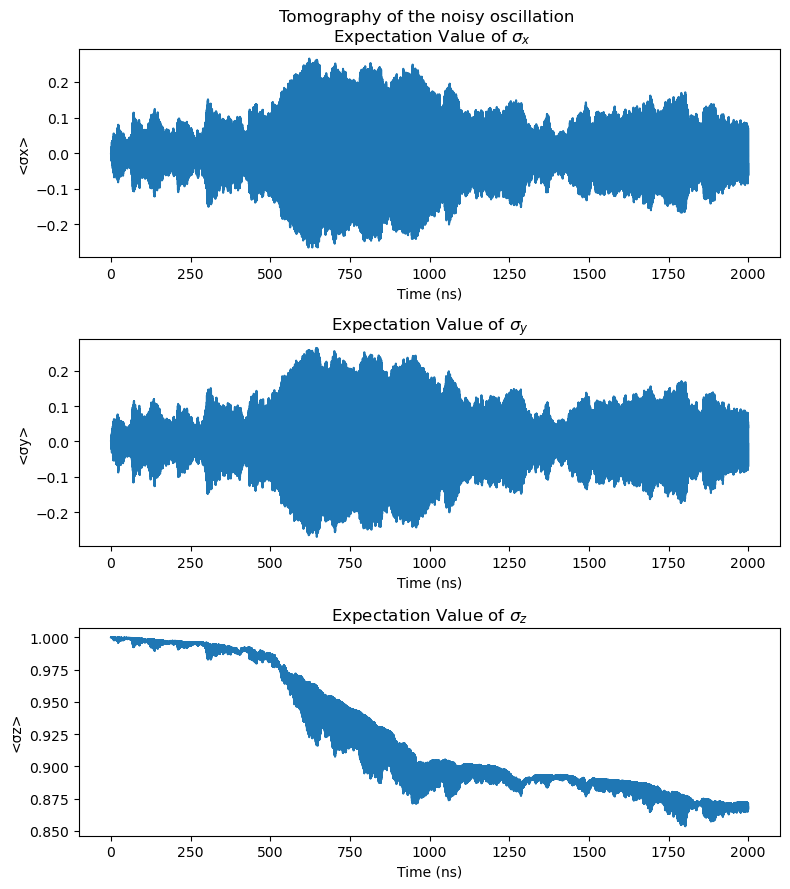

In [8]:
plot_tomography(t, res.expect)

/usr/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


DC: (92256.63115734849+0j)


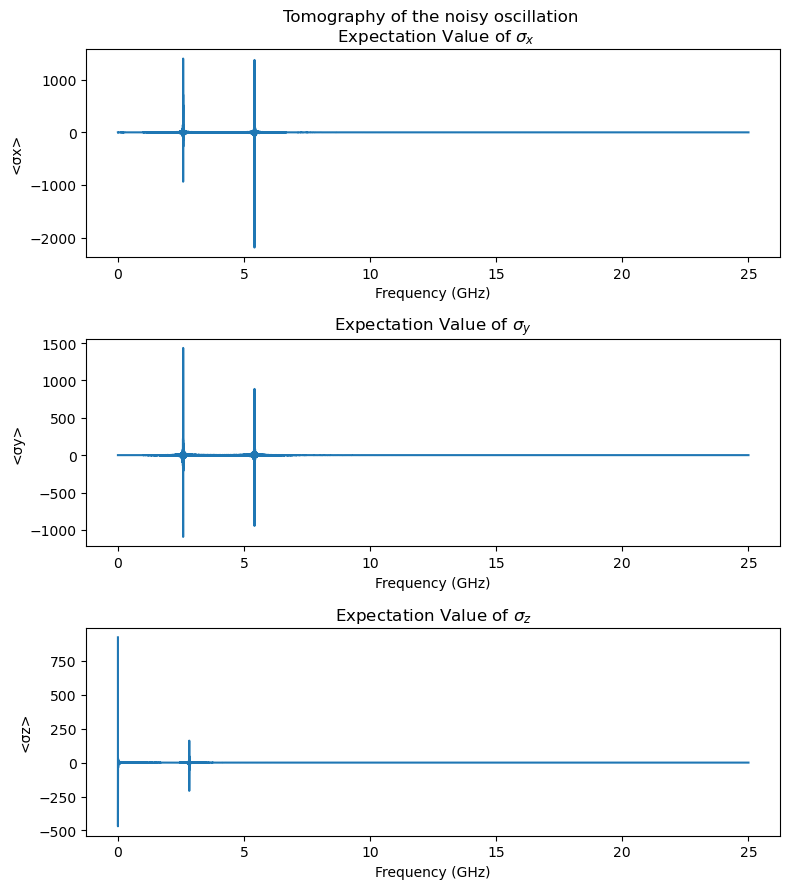

In [13]:
plot_fft_tomography(t, res.expect)

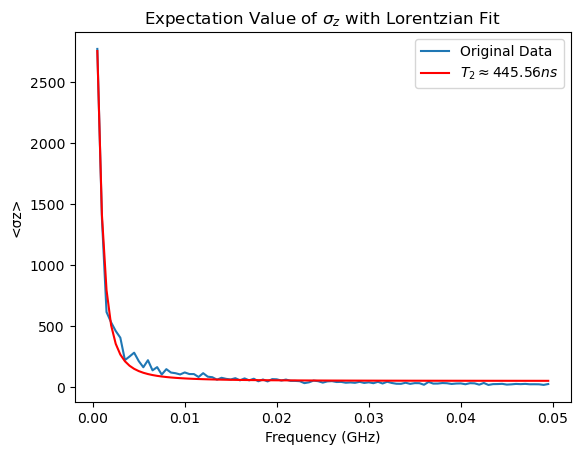

Fitted Offset: 49.26
Fitted Amplitude (S0): 4029.97
Fitted T2 445.56 ns
std of increments (volatility): 4.5236424928079845e-06


In [14]:
lorenztian_fit(t, res.expect[2], T2_0)

Fitted Offset: 1.23
Fitted Amplitude (S0): 193.40
Fitted T2 238.11 ns
Fitted f0 2.83 GHz


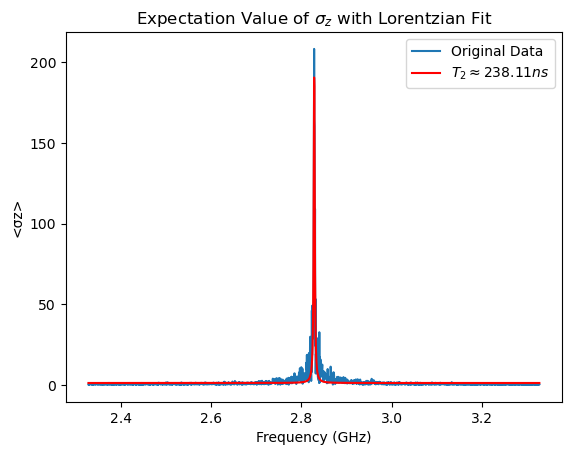

In [19]:
lorenztian_fit2(t, res.expect[2], T2_1, peak)

In [29]:
# parameters

g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]
Ed0=0.128*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi
print(peak)
t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=Ed0)

2.8284271247461903


/usr/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


DC: (85200.30158876548+0j)


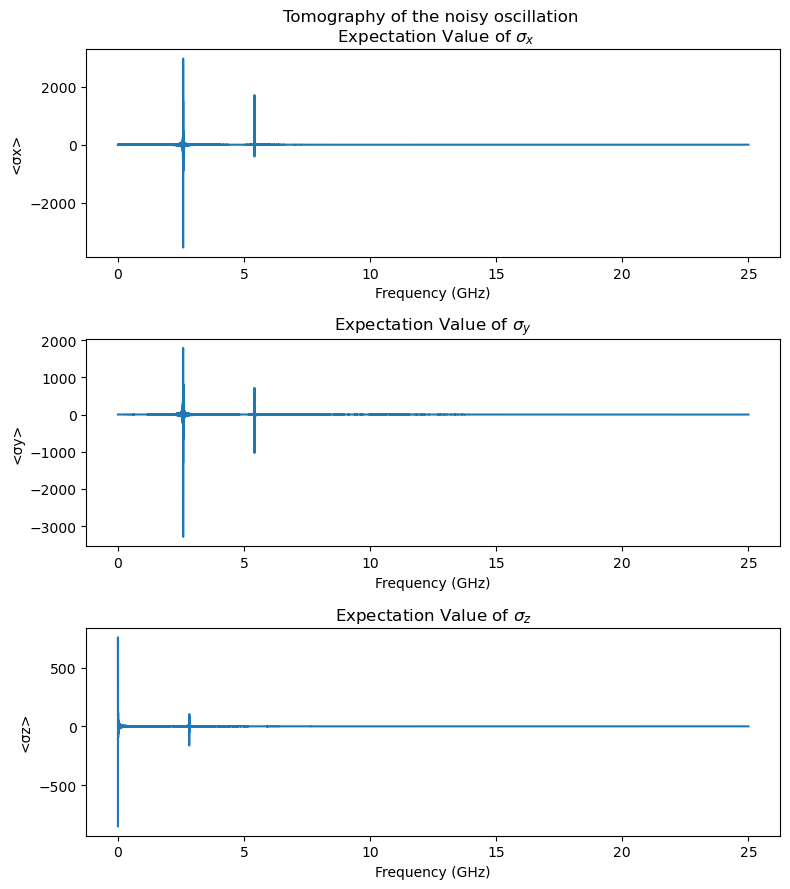

In [30]:
plot_fft_tomography(t, res.expect)

Fitted Offset: 1.52
Fitted Amplitude (S0): 147.75
Fitted T2 120.71 ns
Fitted f0 2.83 GHz


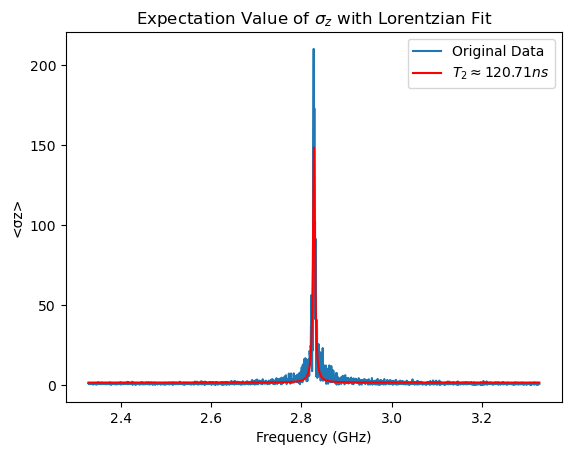

In [31]:
lorenztian_fit2(t, res.expect[2], T2_1, peak=peak)

## Split noise source peak with drive
### Qubit 0 noise

In [28]:
# parameters

g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]
amp0=0.128*2*np.pi #driving energy [GHz.rad]
amp0drive=0.01*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi

def Ed0(tlist):
    return amp0*np.random.normal(0,1,len(tlist))+amp0drive*np.sin((wq1+wq0+2*np.pi*peak)/2*tlist)
print(peak)
t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=Ed0)

2.8284271247461903


/usr/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


DC: (13119.546589796073+0j)


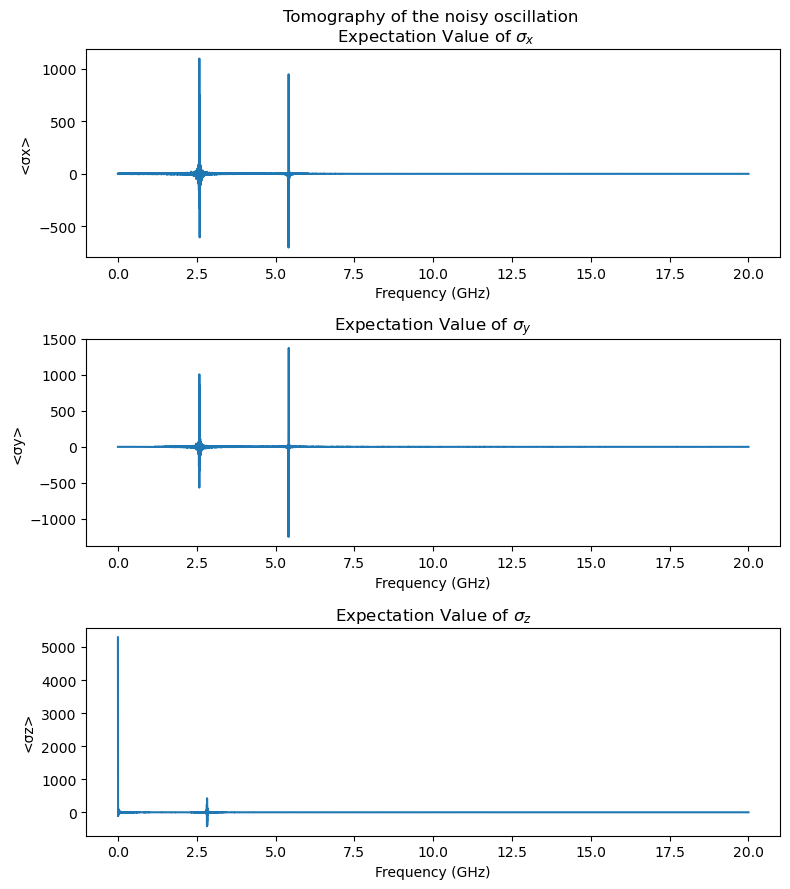

In [29]:
plot_fft_tomography(t, res.expect)

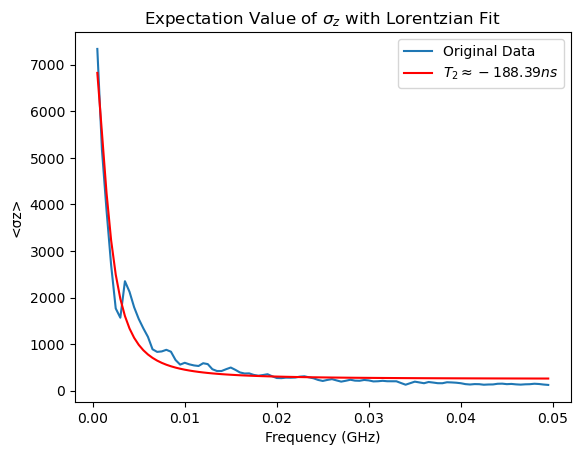

Fitted Offset: 252.96
Fitted Amplitude (S0): 7146.54
Fitted T2 -188.39 ns
std of increments (volatility): 0.00020458845135477543


In [30]:
lorenztian_fit(t, res.expect[2], T2_0)

Fitted Offset: 6.41
Fitted Amplitude (S0): 479.00
Fitted T2 82.71 ns
Fitted f0 2.83 GHz


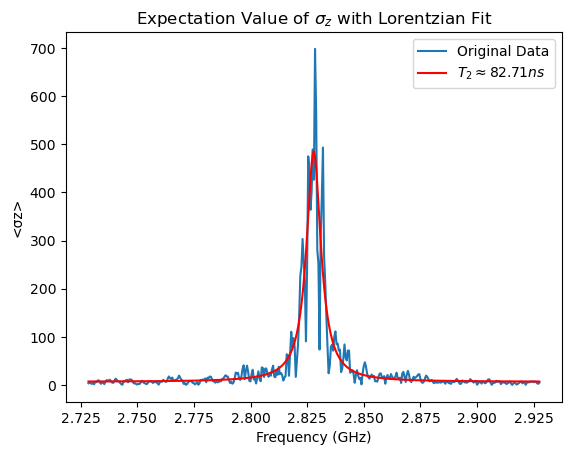

In [31]:
lorenztian_fit2(t, res.expect[2], T2_1, peak=peak,zoom=0.1)

### TLS 1 noise

In [24]:
# parameters

g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]
amp0drive=0.1*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
amp1=0.128*2*np.pi #driving energy [GHz.rad]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi

def Ed0(tlist):
    return amp0drive*np.sin((wq1+wq0+2*np.pi*peak)/2*tlist)
#Ed0=None
def Ed1(tlist):
    return amp1*np.random.normal(0,1,len(tlist))
print(peak)
t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed0=Ed0, Ed1=Ed1)

2.8284271247461903


/usr/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


DC: (17783.555172521425+0j)


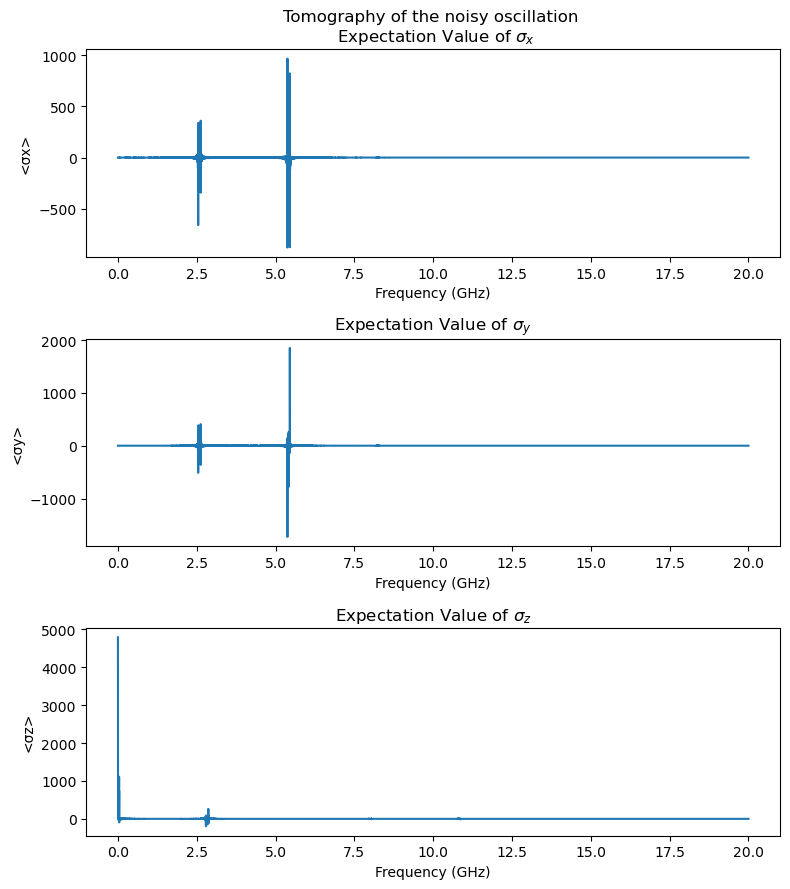

In [25]:
plot_fft_tomography(t, res.expect)

Fitted Offset: 18.59
Fitted Amplitude (S0): 96.61
Fitted T2 231.93 ns
Fitted f0 2.83 GHz


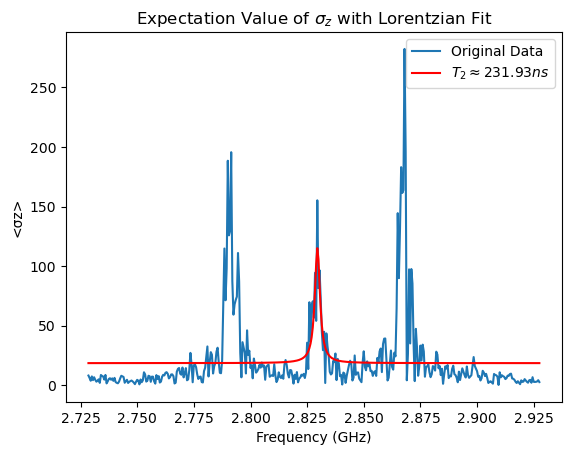

In [26]:
lorenztian_fit2(t, res.expect[2], T2_1, peak=peak,zoom=0.1)

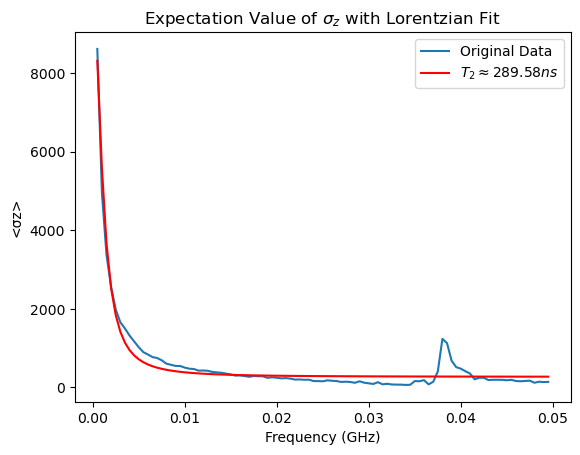

Fitted Offset: 268.83
Fitted Amplitude (S0): 9707.14
Fitted T2 289.58 ns
std of increments (volatility): 4.0206548832742194e-05


In [27]:
lorenztian_fit(t, res.expect[2], T2_1)